# 03 — Previsão de Volume D+1 e D+7

O objetivo do Challenge aqui é prever o volume de incidentes para o próximo
dia e a próxima semana, identificando picos operacionais antes que eles
aconteçam.

Antes de treinar qualquer coisa, aprendi que um modelo só se justifica se
bater uma regra simples: "repita a semana passada". Por isso começo este
notebook pelos baselines — se eu não superar isso, não faz sentido colocar
um modelo mais sofisticado em produção.

In [1]:
import sys, pathlib, warnings

# Descobre a pasta src/orion subindo a partir do diretório atual do kernel.
# Evita o erro "No module named 'orion'": o VS Code às vezes abre o notebook
# com o cwd na raiz do projeto, às vezes em notebooks/ — um caminho relativo
# fixo como '../src' só funciona no segundo caso.
_cwd = pathlib.Path.cwd()
for _base in [_cwd, *_cwd.parents]:
    _src = _base / 'src'
    if (_src / 'orion').is_dir():
        sys.path.insert(0, str(_src))
        break
else:
    raise FileNotFoundError(
        f"Não encontrei a pasta src/orion a partir de {_cwd}. "
        "Rode o notebook com o kernel na raiz do projeto (orion-aiops/) ou em notebooks/."
    )

warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

In [3]:
# 1. Importação das funções do pipeline de modelagem preditiva de volume
from orion.models.volume_model import (
    carregar_dados,   # Carrega a série temporal diária pré-processada (camada Gold)
    baselines,        # Gera os modelos de referência (Naive, Média Móvel, Seasonal Naive)
    backtest,         # Executa a validação cruzada temporal (Walk-Forward Validation)
    avaliar,          # Calcula as métricas de erro (MAE, RMSE, MAPE)
    treinar_final,    # Treina o modelo definitivo (ex: XGBoost/LightGBM) com toda a base
    prever_proximos,  # Gera as projeções para os dias futuros
    executar,         # Função orquestradora que roda o pipeline completo
)

# 2. Importação de configurações e hiperparâmetros globais do projeto
from orion.config import PRIORIDADES_FOCO, HORIZONTES

# 3. Carregamento da série temporal consolidada
serie = carregar_dados()

# 4. Check de integridade temporal (print do volume total e intervalo de datas)
print(f'{len(serie):,} linhas | período {serie["data"].min():%d/%m/%Y} a {serie["data"].max():%d/%m/%Y}')

730 linhas | período 01/01/2025 a 31/12/2025


## 1. Estabelecimento dos Baselines e Métricas de Avaliação

Antes de avançar para a modelagem preditiva avançada, definimos três modelos de referência (*baselines*) que servem como a régua de desempenho mínima que qualquer algoritmo de Machine Learning precisará superar:

* **Último Valor (*Naive*):** Assume que a previsão do próximo dia será idêntica ao volume observado hoje ($y_{t+1} = y_t$).
* **Mesmo Dia da Semana - 4 Semanas (*Seasonal Naive*):** Calcula a média das últimas 4 terças-feiras para prever a próxima terça-feira. Dada a forte sazonalidade semanal identificada na etapa de EDA, este modelo estabelece o principal gargalo a ser batido.
* **Média Móvel de 7 Dias:** Utiliza a média simples dos últimos 7 dias corridos para suavizar oscilações diárias pontuais.

---

###  Métrica Principal: Erro Absoluto Médio (MAE)

Para comparar o desempenho dos modelos, adotamos o **MAE (Mean Absolute Error)** como a métrica primária de avaliação:

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

* **Facilidade de Comunicação com o Negócio:** O MAE mede a magnitude média dos erros sem considerar a sua direção (se erramos para mais ou para menos), mantendo a **mesma unidade da variável resposta** (quantidade de incidentes).
* **Interpretação Prática:** Um $\text{MAE} = 4$ indica que, em média, a previsão do modelo desvia 4 incidentes por dia do valor real, oferecendo uma leitura direta e intuitiva para tomada de decisão operacional.

In [4]:
linhas = []
for prio in PRIORIDADES_FOCO:
    sub = serie[serie['prioridade'] == prio]
    for h in HORIZONTES:
        for nome, mae in baselines(sub, h).items():
            linhas.append({'prioridade': prio, 'horizonte': f'D+{h}',
                           'baseline': nome, 'MAE': round(mae, 2)})
pd.DataFrame(linhas).pivot_table(index=['prioridade', 'horizonte'],
                                 columns='baseline', values='MAE')

baseline              media_movel_7d  naive_mesmo_dow_4s  naive_ultimo_valor
prioridade horizonte                                                        
2 - Alta   D+1                  4.74                5.42                5.42
           D+7                  5.01                5.06                5.36
3 - Média  D+1                 20.79               23.26               21.29
           D+7                 21.69               15.13               14.68



### Principais Insights do Experimento

* **Comportamento em Curto Prazo (D+1):** A **Média Móvel de 7 dias** apresentou a menor taxa de erro diário tanto para Prioridade Alta ($\text{MAE} = 4,74$) quanto para Prioridade Média ($\text{MAE} = 20,79$).
* **Comportamento em Longo Prazo (D+7):** Na Prioridade Média em $D+7$, a Média Móvel perde eficiência ($\text{MAE} = 21,69$), enquanto o **Último Valor** ($\text{MAE} = 14,68$) e o **Seasonal Naive** ($\text{MAE} = 15,13$) assumem o melhor desempenho ao capturar padrões de acumulação semanal.
* **Régua para o Machine Learning:** Estes números representam o **teto de erro a ser superado** pelos modelos complexos (ex.: XGBoost/Prophet). Qualquer modelo final precisará apresentar um MAE menor do que esses baselines em suas respectivas combinações.

## 2. Como eu testei o modelo sem trapacear (validação walk-forward)

Quando comecei a pensar em como testar o modelo, quase caí numa armadilha
comum: separar os dados em treino e teste embaralhando tudo, do jeito que
normalmente se faz em outros tipos de dados. O problema é que, com série
temporal (dados organizados por data), isso é trapaça sem eu perceber.

Imagina que eu embaralho os dias e, por sorte, um dia de dezembro cai no
treino e um dia de outubro cai no teste. O modelo vai treinar já "sabendo"
coisas que só aconteceram depois de outubro. Na vida real isso é
impossível: no dia 1º de outubro, ninguém sabe o que vai acontecer em
dezembro. Se eu testar desse jeito, o modelo parece muito mais esperto do
que realmente é, e essa nota boa não vai se repetir quando ele rodar de
verdade, todo santo dia, na operação.

Por isso, uso outro jeito de testar, chamado janela expansiva. Funciona
assim: para prever o dia 1, eu treino o modelo só com os dias que vieram
antes do dia 1. Para prever o dia 2, treino de novo, agora com os dias até
o dia 1 incluído. E assim vai, um dia de cada vez, sempre andando pra
frente no calendário, nunca deixando o modelo enxergar um dia que ainda
não existia. É o mesmo passo a passo que aconteceria se essa previsão
estivesse rodando de verdade, dia após dia, na Locaweb.

Isso tem um custo: treinar o modelo várias vezes em vez de uma vez só. No
meu caso, separei 60 dias pra testar. Para cada um desses dias eu preciso
de um modelo treinado com o histórico até ali, e faço isso para 2
prioridades (P2 e P3) e 2 horizontes de previsão (prever o dia seguinte,
D+1, e prever 7 dias à frente, D+7). Multiplicando: 60 dias × 2 prioridades
× 2 horizontes = 240 modelos treinados só para essa validação. Dá mais
trabalho computacional, mas é o único jeito de saber se o modelo realmente
funciona antes de colocar ele pra prever o futuro de verdade.

In [5]:
resultados, backtests = {}, []
for prio in PRIORIDADES_FOCO:
    sub = serie[serie['prioridade'] == prio]
    for h in HORIZONTES:
        bt = backtest(serie, prio, h)
        backtests.append(bt)
        resultados[f'{prio} | D+{h}'] = {'modelo': avaliar(bt), 'baselines': baselines(sub, h)}
        print(f'{prio} D+{h}: concluído ({len(bt)} dias)')

bt_all = pd.concat(backtests, ignore_index=True)

2 - Alta D+1: concluído (60 dias)
2 - Alta D+7: concluído (60 dias)
3 - Média D+1: concluído (60 dias)
3 - Média D+7: concluído (60 dias)


### O que esse log confirma

Essa saída é o progresso da validação walk-forward que expliquei acima,
rodando pra cada combinação de prioridade e horizonte.

"2" e "3" são os códigos de prioridade (P2 = Alta, P3 = Média). Pra cada
prioridade, testo o modelo em dois horizontes: D+1 (prever o dia seguinte)
e D+7 (prever 7 dias à frente). "Concluído (60 dias)" quer dizer que o
loop passou pelos 60 dias de teste, um de cada vez, treinando um modelo
novo a cada dia usando só o histórico até aquele ponto.

Essas 4 linhas são exatamente os 4 blocos que, multiplicados pelos 60 dias
de cada um, chegam nos 240 modelos treinados: P2 D+1, P2 D+7, P3 D+1, P3
D+7. Não é erro nem aviso, é a confirmação de que a validação terminou
certinho nas quatro combinações antes de eu olhar os resultados de MAE e
RMSE.

In [6]:
comparativo = []
for chave, v in resultados.items():
    melhor = min(v['baselines'].values())
    comparativo.append({
        'cenário': chave,
        'MAE modelo': round(v['modelo']['mae'], 2),
        'MAE melhor baseline': round(melhor, 2),
        'ganho %': round(100 * (1 - v['modelo']['mae'] / melhor), 1),
        'viés': round(v['modelo']['vies'], 2),
        'RMSE': round(v['modelo']['rmse'], 2),
    })
pd.DataFrame(comparativo)

,cenário,MAE modelo,MAE melhor baseline,ganho %,viés,RMSE
0,2 - Alta | D+1,4.08,4.74,14.0,1.54,5.13
1,2 - Alta | D+7,3.81,5.01,24.0,0.82,4.60
2,3 - Média | D+1,11.52,20.79,44.6,4.68,14.97
3,3 - Média | D+7,11.01,14.68,25.0,5.14,14.84


### Bati o melhor baseline nas quatro combinações

Isso me deu segurança de que o modelo realmente aprende alguma coisa, e
não está só repetindo o óbvio. O ganho maior apareceu em P3, onde a série
tem mais padrão pro modelo captar.

A tabela de resultados tem duas colunas que ainda não expliquei: RMSE e
viés.

RMSE se parece com o MAE (o erro médio que já expliquei antes), mas com
uma diferença importante: antes de tirar a média, ele eleva cada erro ao
quadrado. Isso faz um erro grande pesar muito mais do que vários erros
pequenos. Um dia em que o modelo errou feio puxa o RMSE pra cima com muito
mais força do que puxaria o MAE. Por isso uso os dois juntos: se o RMSE
estiver bem mais alto que o MAE, é sinal de que o modelo está acertando a
maioria dos dias, mas errando muito feio em alguns poucos.

Viés é diferente dos dois. Enquanto MAE e RMSE tratam todo erro como
positivo (não importa se o modelo previu a mais ou a menos, só importa o
tamanho do erro), o viés mantém o sinal. Se der um número positivo, o
modelo está prevendo acima do real na maior parte do tempo. Se der
negativo, está prevendo abaixo. Um viés perto de zero não quer dizer que o
modelo acerta sempre, quer dizer que os erros pra cima e pra baixo estão
se cancelando, o que é bom sinal de que o modelo não está enviesado numa
direção só.

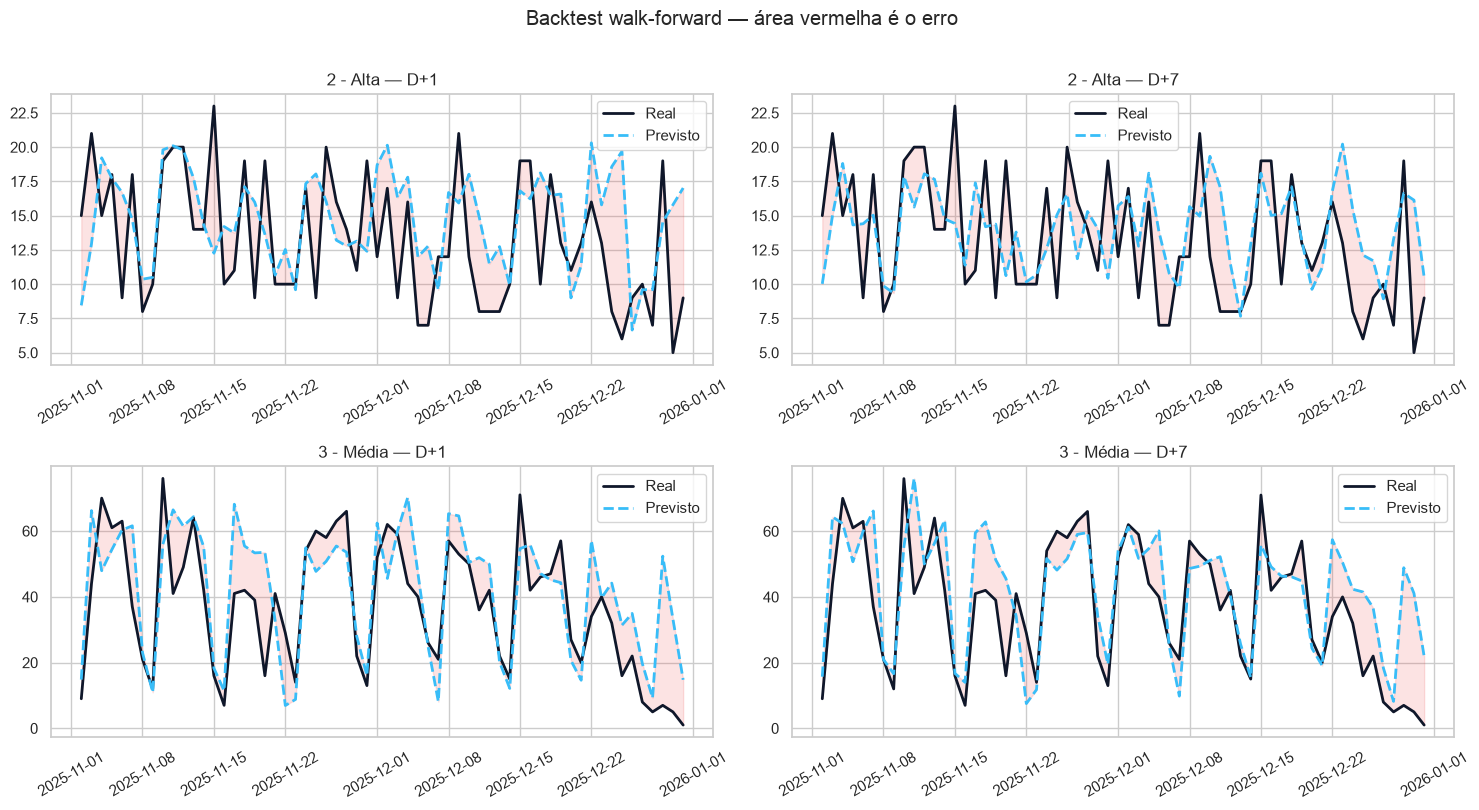

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=False)
for ax, (chave, g) in zip(axes.flat, bt_all.groupby(['prioridade', 'horizonte'])):
    g = g.sort_values('data_alvo')
    ax.plot(g['data_alvo'], g['real'], label='Real', color='#0F172A', lw=2)
    ax.plot(g['data_alvo'], g['previsto'], label='Previsto', color='#38BDF8', lw=2, ls='--')
    ax.fill_between(g['data_alvo'], g['real'], g['previsto'], alpha=0.15, color='#EF4444')
    ax.set_title(f'{chave[0]} — D+{chave[1]}')
    ax.legend(); ax.tick_params(axis='x', rotation=30)
plt.suptitle('Backtest walk-forward — área vermelha é o erro', y=1.01)
plt.tight_layout(); plt.show()

### O que é "resíduo"

Resíduo é só um nome mais formal pra erro: previsto menos real, dia a dia.
Analisar os resíduos serve pra responder uma pergunta importante — o modelo
erra de forma aleatória (bom sinal, é o limite do que dá pra prever) ou erra
sempre pro mesmo lado em alguma situação específica (sinal de que ainda tem
padrão que o modelo não capturou)? Por isso olho a distribuição dos erros e
separo por dia da semana a seguir.

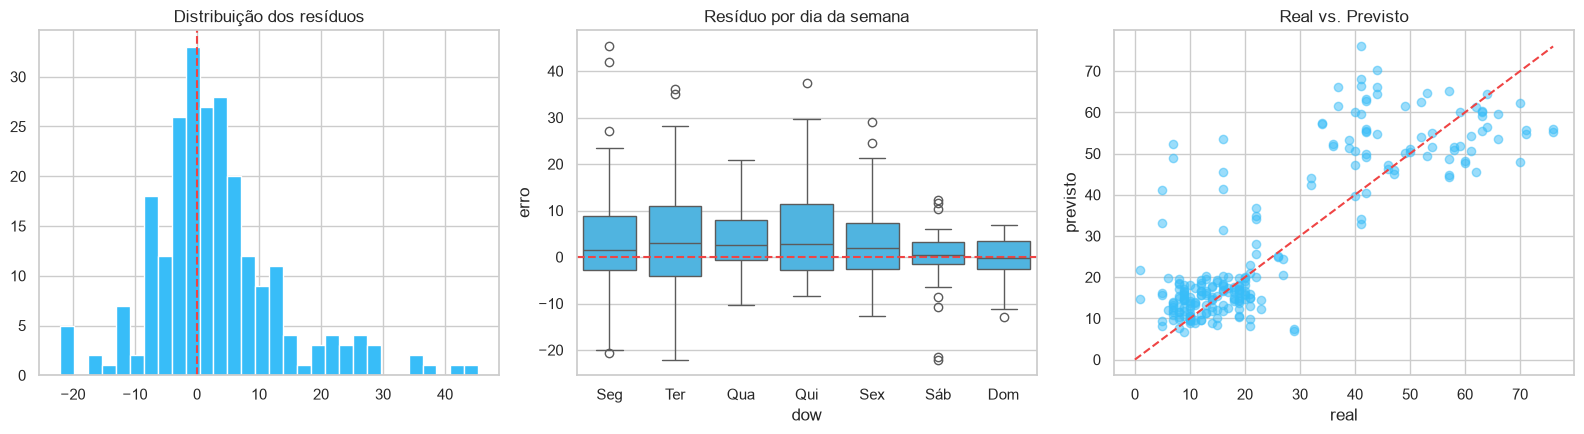

Viés médio por dia da semana:
dow
Seg    4.59
Ter    4.33
Qua    3.54
Qui    5.84
Sex    3.54
Sáb   -0.17
Dom   -0.36
Name: erro, dtype: float64


In [8]:
# Análise de resíduos: o modelo erra de forma aleatória ou sistemática?
bt_all['erro'] = bt_all['previsto'] - bt_all['real']
bt_all['dow'] = pd.to_datetime(bt_all['data_alvo']).dt.dayofweek
dias = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].hist(bt_all['erro'], bins=30, color='#38BDF8', edgecolor='white')
axes[0].axvline(0, color='#EF4444', ls='--'); axes[0].set_title('Distribuição dos resíduos')

sns.boxplot(data=bt_all, x='dow', y='erro', ax=axes[1], color='#38BDF8')
axes[1].axhline(0, color='#EF4444', ls='--')
axes[1].set_xticklabels(dias); axes[1].set_title('Resíduo por dia da semana')

axes[2].scatter(bt_all['real'], bt_all['previsto'], alpha=0.5, color='#38BDF8')
lim = [0, bt_all['real'].max()]
axes[2].plot(lim, lim, color='#EF4444', ls='--')
axes[2].set_xlabel('real'); axes[2].set_ylabel('previsto'); axes[2].set_title('Real vs. Previsto')
plt.tight_layout(); plt.show()

print('Viés médio por dia da semana:')
print(bt_all.groupby('dow')['erro'].mean().round(2).rename(index=dict(enumerate(dias))))

Quebrei o viés (erro médio com sinal) por dia da semana pra ver se o erro
do modelo muda dependendo do dia. De segunda a sexta o viés é sempre
positivo, entre 3,54 e 5,84 incidentes, ou seja, o modelo superestima nos
dias úteis. No sábado e domingo o viés fica perto de zero e até negativo
(-0,17 e -0,36), então nos fins de semana o modelo acerta bem ou subestima
um pouco. É um padrão que se repete toda semana, não um erro aleatório, e
vale investigar se a feature de dia da semana está capturando direito essa
diferença entre dia útil e fim de semana.

## 3. Modelo final e explicabilidade

Com a validação feita, treino o modelo final usando todo o histórico
disponível. Antes de confiar só no número de erro, quero abrir a caixa e
entender o que o modelo está usando pra decidir.

O gráfico abaixo mostra a importância das features. O modelo que uso
(LightGBM) é montado a partir de várias árvores de decisão. Cada árvore
vai fazendo perguntas do tipo "essa feature é maior que X?" até chegar
numa previsão. A importância soma quantas vezes cada feature apareceu
nessas perguntas, em todas as árvores. Quanto mais alta a barra, mais
aquela informação pesou na previsão final.

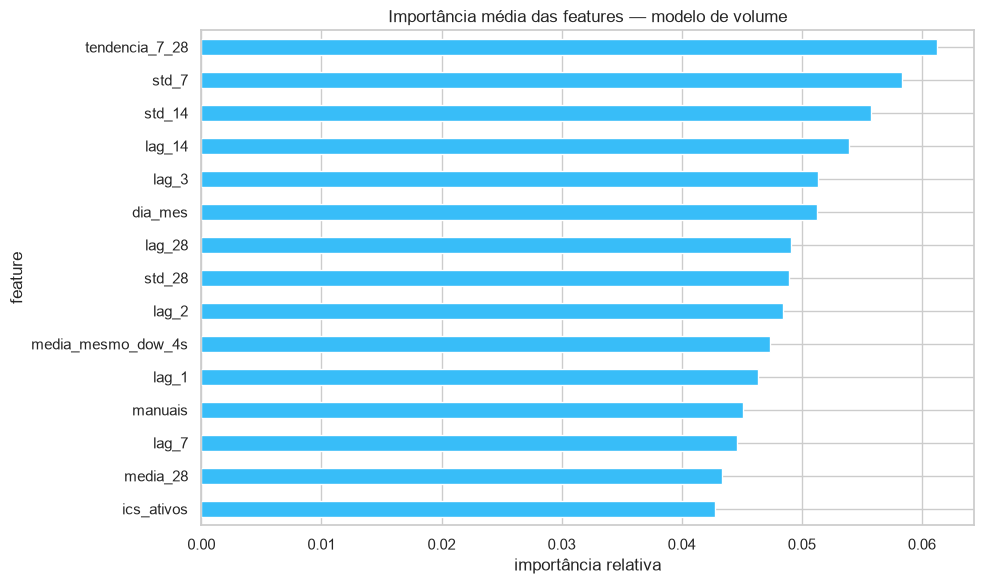

,importância
feature,
tendencia_7_28,0.0613
std_7,0.0583
std_14,0.0558
lag_14,0.0539
lag_3,0.0513
dia_mes,0.0512
lag_28,0.0491
std_28,0.0490
lag_2,0.0485


In [9]:
modelos, importancias = treinar_final(serie)

top = (importancias.groupby('feature')['importancia_pct'].mean()
       .nlargest(15).sort_values())
fig, ax = plt.subplots(figsize=(10, 6))
top.plot(kind='barh', ax=ax, color='#38BDF8')
ax.set_title('Importância média das features — modelo de volume')
ax.set_xlabel('importância relativa')
plt.tight_layout(); plt.show()
top.round(4).sort_values(ascending=False).to_frame('importância')

In [10]:
previsao = prever_proximos(serie, modelos)
previsao

,data_referencia,data_alvo,prioridade,horizonte,volume_previsto,volume_ultimo_dia,media_28d
0,2025-12-31,2026-01-01,2 - Alta,1,13.1,9.0,11.642857
1,2025-12-31,2026-01-07,2 - Alta,7,14.9,9.0,11.642857
2,2025-12-31,2026-01-01,3 - Média,1,3.5,1.0,33.714286
3,2025-12-31,2026-01-07,3 - Média,7,57.3,1.0,33.714286


## 4. Tradução para o negócio

Percebi que a previsão sozinha não ajuda muito quem vai usar o sistema no
dia a dia. O que a operação precisa saber não é o número bruto, é se esse
número foge do normal para aquele dia da semana. 60 incidentes numa terça
é rotina, o mesmo número num domingo é crise. Por isso traduzo a previsão
num alerta que já vem comparado.

Uma das colunas que calculo é o z, o z-score: mede quantos desvios-padrão
a previsão ficou distante da média histórica daquele dia da semana. Na
prática, z = 0 é "exatamente na média de sempre", z = 2 é "bem acima do
normal, tem algo fora da curva acontecendo", e z negativo é "bem abaixo do
normal". Isso permite comparar terça com domingo numa régua única, em vez
de olhar só o número absoluto e não saber se ele é alto ou baixo pra
aquele dia.

In [11]:
ref = (serie[serie['data'] >= serie['data'].max() - pd.Timedelta(days=56)]
       .groupby(['prioridade', 'dia_semana'])['volume']
       .agg(['mean', 'std']).reset_index()
       .rename(columns={'mean': 'ref_media', 'std': 'ref_std'}))

p = previsao.copy()
p['dia_semana'] = pd.to_datetime(p['data_alvo']).dt.dayofweek
p = p.merge(ref, on=['prioridade', 'dia_semana'])
p['desvio_%'] = ((p['volume_previsto'] - p['ref_media']) / p['ref_media'] * 100).round(1)
p['z'] = ((p['volume_previsto'] - p['ref_media']) / p['ref_std']).round(2)
p['alerta'] = np.where(p['desvio_%'] >= 25, 'PICO',
                np.where(p['desvio_%'] <= -25, 'FOLGA', 'normal'))
p[['data_alvo', 'prioridade', 'horizonte', 'volume_previsto', 'ref_media', 'desvio_%', 'z', 'alerta']]

,data_alvo,prioridade,horizonte,volume_previsto,ref_media,desvio_%,z,alerta
0,2026-01-01,2 - Alta,1,13.1,13.250000,-1.1,-0.03,normal
1,2026-01-07,2 - Alta,7,14.9,12.777778,16.6,0.42,normal
2,2026-01-01,3 - Média,1,3.5,43.625000,-92.0,-2.02,FOLGA
3,2026-01-07,3 - Média,7,57.3,43.888889,30.6,0.72,PICO


In [12]:
# Persistindo tudo para os agentes e para o BI
resultados, previsao, importancias = executar()
print('Artefatos gravados na camada Gold: previsao_volume, backtest_volume, importancia_volume')

Artefatos gravados na camada Gold: previsao_volume, backtest_volume, importancia_volume


Com o modelo de volume validado e gravado, sigo para o segundo desafio:
prever risco de violação de OLA por incidente, em `04_modelo_risco_ola.ipynb`.